In [1]:
import pathlib
import subprocess
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re
import glob
import h5py
import matplotlib.animation as animation

import scipy.special as spl
import scipy.integrate
import mpmath as mpm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
import matplotlib.cm as cm

fontsize_title = 22
fontsize_axis = 18
fontsize_tick = 18
fontsize_legend = 16
fontsize_cbar = 18

plt.rcParams.update({
    "font.size": fontsize_tick,
    "axes.titlesize": fontsize_title,
    "axes.labelsize": fontsize_axis,
    "xtick.labelsize": fontsize_tick,
    "ytick.labelsize": fontsize_tick,
    "legend.fontsize": fontsize_legend,
    "figure.titlesize": fontsize_title,
})

In [2]:
import os

os.getcwd()

'/net/fs06/d0/dabdulah/GFD_PROJECT/crust_convection/mantle3D_xyperiodic_erosion_v1'

In [3]:
### 3-PANEL ANIMATION: p, h, C(z=z_index) ###

def make_p_h_C_animation(
    snapshot_dir="snapshots",
    file_prefix="snapshots_s",
    output_name="p_h_C_animation.gif",

    p_task="p",
    h_task="h",
    C_task="C",

    p_z_index=None,    # None means p is already 2D; otherwise slice p[:, :, z_index]
    h_z_index=None,    # None means h is already 2D; otherwise slice h[:, :, z_index]
    C_z_index=-2,      # C is sliced at this z index

    titles=("p", "h", "C"),

    cmaps=("RdBu_r", "RdBu_r", "RdBu_r"),
    vmins=(None, None, None),
    vmaxs=(None, None, None),

    fps=4,
    framecutoff=None,
    max_frames=None,   # evenly sample at most this many frames
    dpi=150,
    figsize=(15, 4.5),
    scale_from_last_half=True,
):
    """
    Makes a 3-panel animation:
        panel 1: p
        panel 2: h
        panel 3: C at C_z_index
    """

    def natural_sort_key(path):
        return [int(s) if s.isdigit() else s for s in re.split(r"(\d+)", path)]

    def get_coord(dset, dim_index):
        keys = list(dset.dims[dim_index].keys())
        if len(keys) == 0:
            raise ValueError(f"No coordinate scale found for dimension {dim_index}")
        return np.asarray(dset.dims[dim_index][keys[0]])

    def find_snapshot_files(snapshot_dir, file_prefix):
        files = []
        i = 1
        while True:
            fname = os.path.join(snapshot_dir, f"{file_prefix}{i}.h5")
            if os.path.exists(fname):
                files.append(fname)
                i += 1
            else:
                break

        if len(files) == 0:
            files = sorted(glob.glob(os.path.join(snapshot_dir, "*.h5")), key=natural_sort_key)

        if len(files) == 0:
            raise FileNotFoundError(f"No snapshot files found in {snapshot_dir}")

        return files

    def read_xy_slice(file, task, it, z_index=None):
        dset = file["tasks"][task]

        if len(dset.shape) == 3:
            return np.asarray(dset[it, :, :])

        elif len(dset.shape) == 4:
            if z_index is None:
                raise ValueError(f"{task} is 3D, so you must provide a z_index")
            return np.asarray(dset[it, :, :, z_index])

        else:
            raise ValueError(f"Unexpected shape for {task}: {dset.shape}")

    def get_xy_coords(dset):
        x = get_coord(dset, 1)
        y = get_coord(dset, 2)
        return x, y

    # ----------------------------
    # Find files and collect frames
    # ----------------------------
    files = find_snapshot_files(snapshot_dir, file_prefix)
    print(f"Found {len(files)} files.")

    frames = []

    for fname in files:
        print(f"Scanning {fname}")
        with h5py.File(fname, "r") as f:
            dset = f["tasks"][p_task]
            t = np.asarray(dset.dims[0]["sim_time"])
            nt = dset.shape[0]

            for it in range(nt):
                frames.append((fname, it, t[it]))

    frames = sorted(frames, key=lambda x: x[2])
    print(f"Total available frames: {len(frames)}")

    # ----------------------------
    # Evenly subsample frames
    # ----------------------------
    if max_frames is not None and max_frames < len(frames):
        inds = np.linspace(0, len(frames) - 1, max_frames).astype(int)
        frames = [frames[i] for i in inds]
        print(f"Using {len(frames)} evenly sampled frames.")

    # ----------------------------
    # Coordinates
    # ----------------------------
    first_fname, first_it, first_time = frames[0]

    with h5py.File(first_fname, "r") as f:
        try:
            x, y = get_xy_coords(f["tasks"][p_task])
        except Exception:
            try:
                x, y = get_xy_coords(f["tasks"][h_task])
            except Exception:
                x, y = get_xy_coords(f["tasks"][C_task])

    X, Y = np.meshgrid(x, y, indexing="ij")

    print("x shape:", x.shape, "min/max:", x.min(), x.max())
    print("y shape:", y.shape, "min/max:", y.min(), y.max())
    print("C_z_index:", C_z_index)

    # ----------------------------
    # Color limits
    # ----------------------------
    tasks = (p_task, h_task, C_task)
    z_indices = (p_z_index, h_z_index, C_z_index)

    vmins = list(vmins)
    vmaxs = list(vmaxs)

    scan_frames = frames[len(frames)//2:] if scale_from_last_half else frames

    for i, (task, zi) in enumerate(zip(tasks, z_indices)):
        if vmins[i] is not None and vmaxs[i] is not None:
            continue

        vals = []
        print(f"Scanning color limits for {task}...")

        for fname, it, sim_time in scan_frames:
            with h5py.File(fname, "r") as f:
                A = read_xy_slice(f, task, it, zi)
                vals.append(np.nanmin(A))
                vals.append(np.nanmax(A))

        if vmins[i] is None:
            vmins[i] = np.nanmin(vals)
        if vmaxs[i] is None:
            vmaxs[i] = np.nanmax(vals)

        print(f"{task} vmin/vmax:", vmins[i], vmaxs[i])

    # ----------------------------
    # Figure setup
    # ----------------------------
    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)
    ims = []

    with h5py.File(first_fname, "r") as f:
        for ax, task, title, cmap, vmin, vmax, zi in zip(
            axes, tasks, titles, cmaps, vmins, vmaxs, z_indices
        ):
            A0 = read_xy_slice(f, task, first_it, zi)

            if cmap is None:
                cmap = mcolors.LinearSegmentedColormap.from_list(
                    "brown_to_red",
                    [
                        (0.00, "black"),
                        (0.25, "saddlebrown"),
                        (1.00, "lightcoral"),
                    ]
                )

            im = ax.pcolormesh(
                X, Y, A0,
                shading="auto",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
            )

            ax.set_title(title)
            ax.set_xlabel("x")
            ax.set_ylabel("y")

            fig.colorbar(im, ax=ax, shrink=0.85)
            ims.append(im)

    fig.suptitle(f"time = {first_time:.2f}")

    # ----------------------------
    # Animation update
    # ----------------------------
    def update(frame_number):
        fname, it, sim_time = frames[frame_number]

        with h5py.File(fname, "r") as f:
            for im, task, zi in zip(ims, tasks, z_indices):
                A = read_xy_slice(f, task, it, zi)
                im.set_array(A.ravel())

        fig.suptitle(f"time = {sim_time:.2f}")

        print(
            f"Frame {frame_number + 1}/{framenum}: "
            f"{fname}, index {it}, time {sim_time:.2f}"
        )

        return ims

    if framecutoff:
        framenum = min(framecutoff, len(frames))
    else:
        framenum = len(frames)

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=framenum,
        interval=1000 / fps,
        blit=False,
    )

    ani.save(output_name, writer="pillow", fps=fps, dpi=dpi)
    print(f"Saved animation to {output_name}")

Found 21 files.
Scanning snapshots_noerosion/snapshots_noerosion_s1.h5
Scanning snapshots_noerosion/snapshots_noerosion_s2.h5
Scanning snapshots_noerosion/snapshots_noerosion_s3.h5
Scanning snapshots_noerosion/snapshots_noerosion_s4.h5
Scanning snapshots_noerosion/snapshots_noerosion_s5.h5
Scanning snapshots_noerosion/snapshots_noerosion_s6.h5
Scanning snapshots_noerosion/snapshots_noerosion_s7.h5
Scanning snapshots_noerosion/snapshots_noerosion_s8.h5
Scanning snapshots_noerosion/snapshots_noerosion_s9.h5
Scanning snapshots_noerosion/snapshots_noerosion_s10.h5
Scanning snapshots_noerosion/snapshots_noerosion_s11.h5
Scanning snapshots_noerosion/snapshots_noerosion_s12.h5
Scanning snapshots_noerosion/snapshots_noerosion_s13.h5
Scanning snapshots_noerosion/snapshots_noerosion_s14.h5
Scanning snapshots_noerosion/snapshots_noerosion_s15.h5
Scanning snapshots_noerosion/snapshots_noerosion_s16.h5
Scanning snapshots_noerosion/snapshots_noerosion_s17.h5
Scanning snapshots_noerosion/snapshots_no

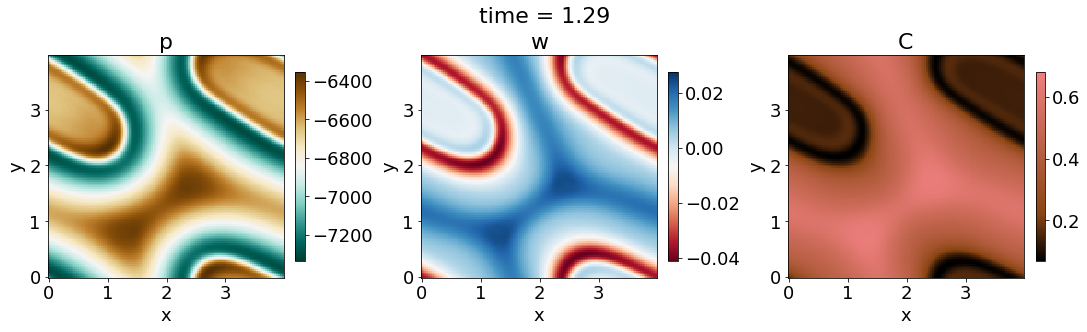

In [4]:
make_p_h_C_animation(
    snapshot_dir="snapshots_noerosion",
    file_prefix="snapshots_noerosion_s",
    output_name="p_h_C_noerosion.gif",

    p_task="p",
    h_task="w",
    C_task="C",

    p_z_index=-1,     # use None if p is already saved as 2D top surface
    h_z_index=-1,   # h should usually be 2D
    C_z_index=-4,

    titles=("p", "w", "C"),

    cmaps=("BrBG_r", "RdBu", None),
    vmins=(None, None, None),
    vmaxs=(None, None, None),

    fps=4,
    framecutoff=None,
    max_frames=100,
    dpi=150,
    figsize=(15, 4.5),
)

In [6]:
fname = "snapshots_noerosion/snapshots_noerosion_s17.h5"
task = "w"

with h5py.File(fname, "r") as f:
    d = f["tasks"][task]
    A = np.asarray(d)
    x = np.asarray(d.dims[1][list(d.dims[1].keys())[0]])
    y = np.asarray(d.dims[2][list(d.dims[2].keys())[0]])
    z = np.asarray(d.dims[3][list(d.dims[3].keys())[0]])

print(A.shape)

(10, 128, 128, 64)


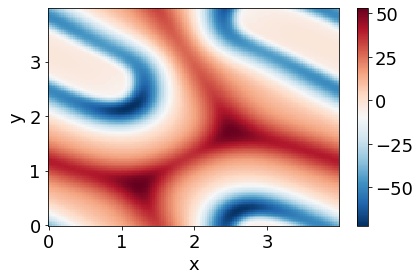

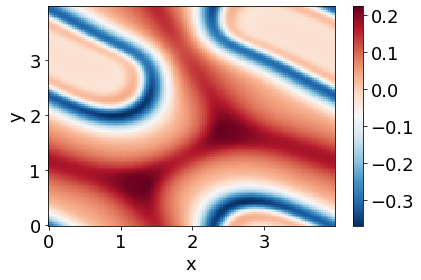

In [10]:
A_slice = A[-1,:,:,32]
X, Y = np.meshgrid(x, y, indexing="ij")

plt.figure(figsize=(6, 4))
plt.pcolormesh(X, Y, A_slice, shading="auto", cmap="RdBu_r")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()
plt.tight_layout()
plt.show()

A_slice = A[-1,:,:,-2]
X, Y = np.meshgrid(x, y, indexing="ij")

plt.figure(figsize=(6, 4))
plt.pcolormesh(X, Y, A_slice, shading="auto", cmap="RdBu_r")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()
plt.tight_layout()
plt.show()

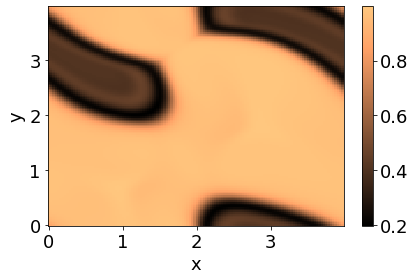

In [27]:
A_slice = A[-1,:,:,-8]
X, Y = np.meshgrid(x, y, indexing="ij")

plt.figure(figsize=(6, 4))
plt.pcolormesh(X, Y, A_slice, shading="auto", cmap="copper")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()
plt.tight_layout()
plt.show()

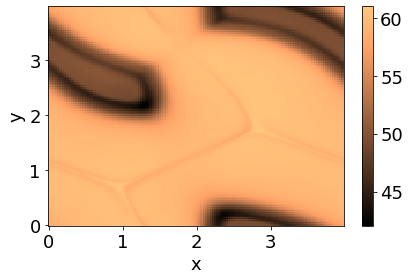

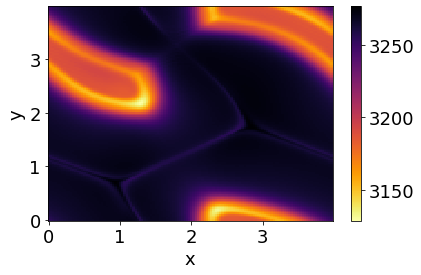

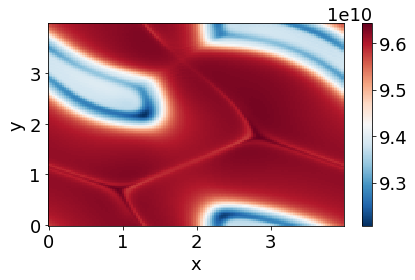

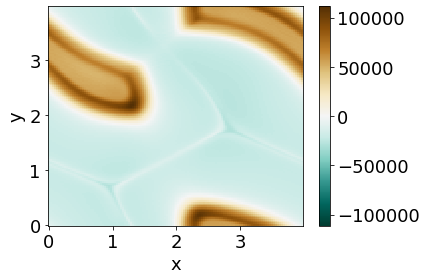

In [57]:
A_slice = np.sum(A[-1,:,:,:],axis=-1)
X, Y = np.meshgrid(x, y, indexing="ij")

rho_m = 3.3e3
rho_c = 2.8e3
density = (A_slice/64)*rho_m + ((64 - A_slice)/64)*rho_c
weight = (density)*9.81*3e6

eta = (np.mean(weight) - weight)/(9.81*density)

plt.figure(figsize=(6, 4))
plt.pcolormesh(X, Y, A_slice, shading="auto", cmap="copper")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.pcolormesh(X, Y, density, shading="auto", cmap="inferno_r")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.pcolormesh(X, Y, weight, shading="auto", cmap="RdBu_r")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.pcolormesh(X, Y, eta, shading="auto", cmap="BrBG_r", vmin=-np.max(eta), vmax = np.max(eta))
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()
plt.tight_layout()
plt.show()

In [58]:
print(np.sum(eta))

6155321.545391694


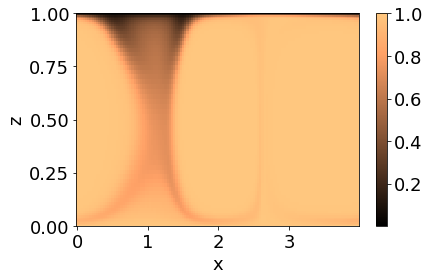

In [28]:
A_slice = A[-1,:,70,:]
X, Z = np.meshgrid(x, z, indexing="ij")

plt.figure(figsize=(6, 4))
plt.pcolormesh(X, Z, A_slice, shading="auto", cmap="copper")
plt.xlabel("x")
plt.ylabel("z")
plt.colorbar()
plt.tight_layout()
plt.show()

In [12]:
fname = "snapshots_noerosion/snapshots_noerosion_s17.h5"
task = "p"

with h5py.File(fname, "r") as f:
    d = f["tasks"][task]
    A = np.asarray(d)
    x = np.asarray(d.dims[1][list(d.dims[1].keys())[0]])
    y = np.asarray(d.dims[2][list(d.dims[2].keys())[0]])
    z = np.asarray(d.dims[3][list(d.dims[3].keys())[0]])

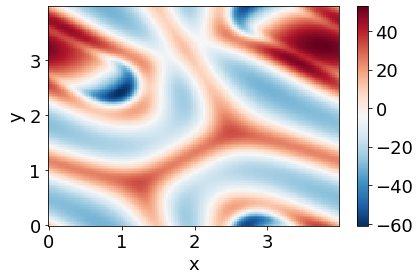

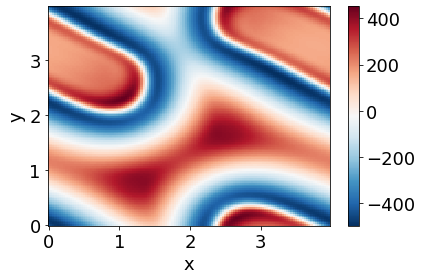

In [14]:
A_slice = A[-1,:,:,32]
A_slice = A_slice - np.mean(A_slice)
X, Y = np.meshgrid(x, y, indexing="ij")

plt.figure(figsize=(6, 4))
plt.pcolormesh(X, Y, A_slice, shading="auto", cmap="RdBu_r")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()
plt.tight_layout()
plt.show()

A_slice = A[-1,:,:,-1]
A_slice = A_slice - np.mean(A_slice)
X, Y = np.meshgrid(x, y, indexing="ij")

plt.figure(figsize=(6, 4))
plt.pcolormesh(X, Y, A_slice, shading="auto", cmap="RdBu_r")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()
plt.tight_layout()
plt.show()

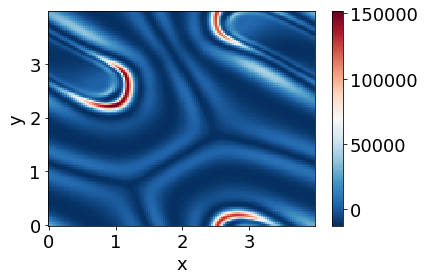

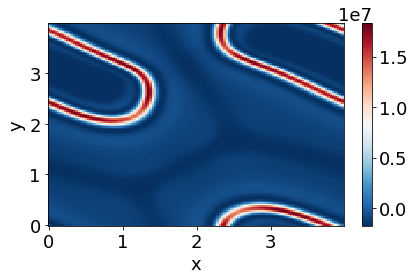

In [36]:
dx = x[1] - x[0]
dy = y[1] - y[0]

A_slice = (np.roll(A[-1,:,:,32],-1,axis=0) - A[-1,:,:,32])**2/dx**2 + (np.roll(A[-1,:,:,32],-1,axis=1) - A[-1,:,:,32])**2/dy**2
A_slice = A_slice - np.mean(A_slice)
X, Y = np.meshgrid(x, y, indexing="ij")

plt.figure(figsize=(6, 4))
plt.pcolormesh(X, Y, A_slice, shading="auto", cmap="RdBu_r")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()
plt.tight_layout()
plt.show()

A_slice = (np.roll(A[-1,:,:,-1],-1,axis=0) - A[-1,:,:,-1])**2/dx**2 + (np.roll(A[-1,:,:,-1],-1,axis=1) - A[-1,:,:,-1])**2/dy**2
A_slice = A_slice - np.mean(A_slice)
X, Y = np.meshgrid(x, y, indexing="ij")

plt.figure(figsize=(6, 4))
plt.pcolormesh(X, Y, A_slice, shading="auto", cmap="RdBu_r")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()
plt.tight_layout()
plt.show()

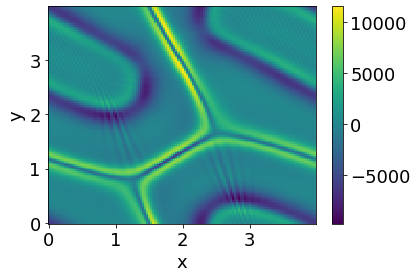

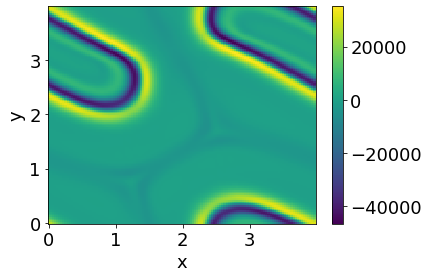

In [40]:
A_slice = A[-1,:,:,1]

lap_A = (
    (np.roll(A_slice, -1, axis=0) - 2*A_slice + np.roll(A_slice, 1, axis=0)) / dx**2
  + (np.roll(A_slice, -1, axis=1) - 2*A_slice + np.roll(A_slice, 1, axis=1)) / dy**2
)

# plot on same axes
X, Y = np.meshgrid(x, y, indexing="ij")

plt.pcolormesh(X, Y, lap_A, shading="auto")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()
plt.show()

A_slice = A[-1,:,:,-1]

lap_A = (
    (np.roll(A_slice, -1, axis=0) - 2*A_slice + np.roll(A_slice, 1, axis=0)) / dx**2
  + (np.roll(A_slice, -1, axis=1) - 2*A_slice + np.roll(A_slice, 1, axis=1)) / dy**2
)

# plot on same axes
X, Y = np.meshgrid(x, y, indexing="ij")

plt.pcolormesh(X, Y, lap_A, shading="auto")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()
plt.show()

Found 9 files.
Scanning snapshots_Kh/snapshots_Kh_s1.h5
Scanning snapshots_Kh/snapshots_Kh_s2.h5
Scanning snapshots_Kh/snapshots_Kh_s3.h5
Scanning snapshots_Kh/snapshots_Kh_s4.h5
Scanning snapshots_Kh/snapshots_Kh_s5.h5
Scanning snapshots_Kh/snapshots_Kh_s6.h5
Scanning snapshots_Kh/snapshots_Kh_s7.h5
Scanning snapshots_Kh/snapshots_Kh_s8.h5
Scanning snapshots_Kh/snapshots_Kh_s9.h5
Total available frames: 87
x shape: (128,) min/max: 0.0 3.96875
y shape: (128,) min/max: 0.0 3.96875
C_z_index: -4
Scanning color limits for p...
p vmin/vmax: -7423.722503173738 -6405.357084647091
Scanning color limits for w...
w vmin/vmax: -0.12861446617126757 0.15056097870547325
Scanning color limits for C...
C vmin/vmax: 0.07208285994681579 0.6885560051663051
Frame 1/87: snapshots_Kh/snapshots_Kh_s1.h5, index 0, time 0.00
Frame 1/87: snapshots_Kh/snapshots_Kh_s1.h5, index 0, time 0.00
Frame 2/87: snapshots_Kh/snapshots_Kh_s1.h5, index 1, time 0.05
Frame 3/87: snapshots_Kh/snapshots_Kh_s1.h5, index 2, time 

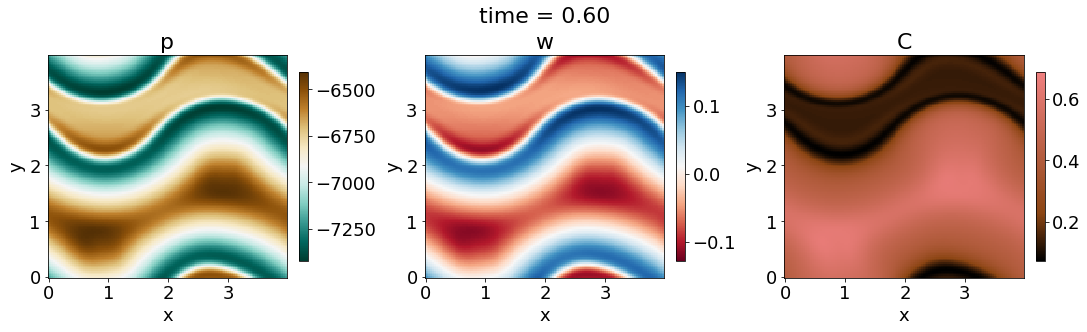

In [5]:
make_p_h_C_animation(
    snapshot_dir="snapshots_Kh",
    file_prefix="snapshots_Kh_s",
    output_name="p_h_C_Kh.gif",

    p_task="p",
    h_task="w",
    C_task="C",

    p_z_index=-1,     # use None if p is already saved as 2D top surface
    h_z_index=-1,   # h should usually be 2D
    C_z_index=-4,

    titles=("p", "w", "C"),

    cmaps=("BrBG_r", "RdBu", None),
    vmins=(None, None, None),
    vmaxs=(None, None, None),

    fps=4,
    framecutoff=None,
    max_frames=100,
    dpi=150,
    figsize=(15, 4.5),
)

Found 1 files.
Scanning snapshots_Kc/snapshots_Kc_s1.h5
Total available frames: 2
x shape: (128,) min/max: 0.0 3.96875
y shape: (128,) min/max: 0.0 3.96875
C_z_index: -4
Scanning color limits for p...
p vmin/vmax: -8239.307415540912 -7812.329508763744
Scanning color limits for w...
w vmin/vmax: -0.43534430533391744 0.47253220873385327
Scanning color limits for C...
C vmin/vmax: 0.12130713331303392 0.5290206572860837
Frame 1/2: snapshots_Kc/snapshots_Kc_s1.h5, index 0, time 0.00
Frame 1/2: snapshots_Kc/snapshots_Kc_s1.h5, index 0, time 0.00
Frame 2/2: snapshots_Kc/snapshots_Kc_s1.h5, index 1, time 0.05
Saved animation to p_h_C_Kc.gif


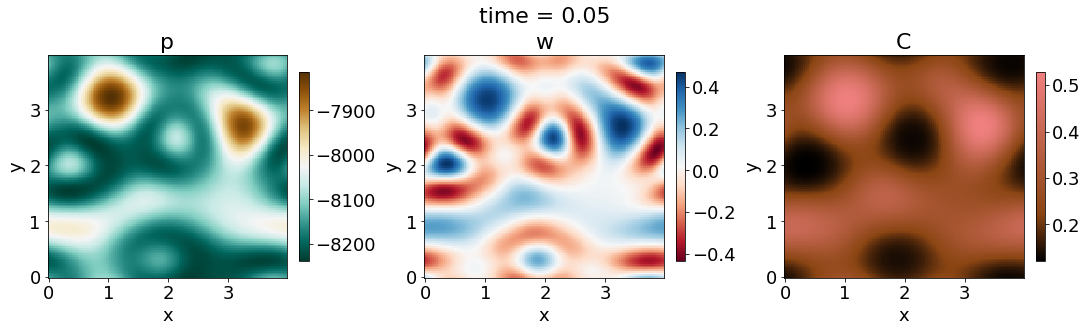

In [6]:
make_p_h_C_animation(
    snapshot_dir="snapshots_Kc",
    file_prefix="snapshots_Kc_s",
    output_name="p_h_C_Kc.gif",

    p_task="p",
    h_task="w",
    C_task="C",

    p_z_index=-1,     # use None if p is already saved as 2D top surface
    h_z_index=-1,   # h should usually be 2D
    C_z_index=-4,

    titles=("p", "w", "C"),

    cmaps=("BrBG_r", "RdBu", None),
    vmins=(None, None, None),
    vmaxs=(None, None, None),

    fps=4,
    framecutoff=None,
    max_frames=100,
    dpi=150,
    figsize=(15, 4.5),
)

Found 1 files.
Scanning snapshots_Ks/snapshots_Ks_s1.h5
Total available frames: 8
x shape: (128,) min/max: 0.0 3.96875
y shape: (128,) min/max: 0.0 3.96875
C_z_index: -4
Scanning color limits for p...


<ipython-input-3-d1861a5aba59>:153: RuntimeWarning: All-NaN slice encountered
  vals.append(np.nanmin(A))
<ipython-input-3-d1861a5aba59>:154: RuntimeWarning: All-NaN slice encountered
  vals.append(np.nanmax(A))
<ipython-input-3-d1861a5aba59>:157: RuntimeWarning: All-NaN axis encountered
  vmins[i] = np.nanmin(vals)
<ipython-input-3-d1861a5aba59>:159: RuntimeWarning: All-NaN axis encountered
  vmaxs[i] = np.nanmax(vals)


p vmin/vmax: nan nan
Scanning color limits for w...
w vmin/vmax: nan nan
Scanning color limits for C...
C vmin/vmax: nan nan
Frame 1/8: snapshots_Ks/snapshots_Ks_s1.h5, index 0, time 0.00
Frame 1/8: snapshots_Ks/snapshots_Ks_s1.h5, index 0, time 0.00
Frame 2/8: snapshots_Ks/snapshots_Ks_s1.h5, index 1, time 0.05
Frame 3/8: snapshots_Ks/snapshots_Ks_s1.h5, index 2, time 0.05
Frame 4/8: snapshots_Ks/snapshots_Ks_s1.h5, index 3, time 0.05
Frame 5/8: snapshots_Ks/snapshots_Ks_s1.h5, index 4, time 0.05
Frame 6/8: snapshots_Ks/snapshots_Ks_s1.h5, index 5, time 0.05
Frame 7/8: snapshots_Ks/snapshots_Ks_s1.h5, index 6, time 0.05
Frame 8/8: snapshots_Ks/snapshots_Ks_s1.h5, index 7, time 0.05
Saved animation to p_h_C_Ks.gif


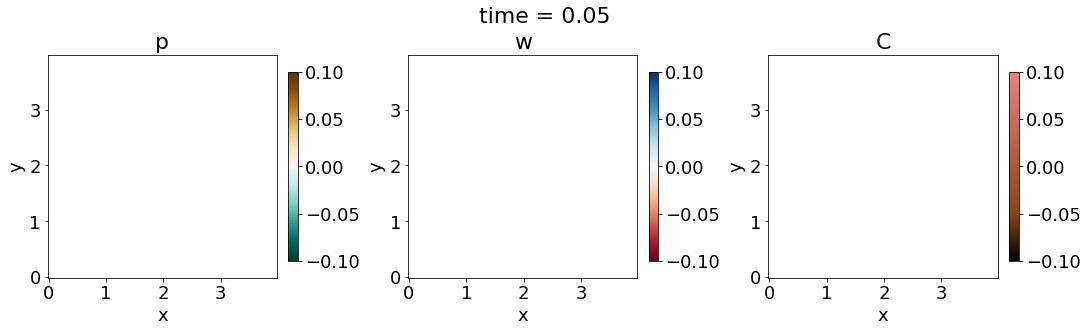

In [4]:
make_p_h_C_animation(
    snapshot_dir="snapshots_Ks",
    file_prefix="snapshots_Ks_s",
    output_name="p_h_C_Ks.gif",

    p_task="p",
    h_task="w",
    C_task="C",

    p_z_index=-1,     # use None if p is already saved as 2D top surface
    h_z_index=-1,   # h should usually be 2D
    C_z_index=-4,

    titles=("p", "w", "C"),

    cmaps=("BrBG_r", "RdBu", None),
    vmins=(None, None, None),
    vmaxs=(None, None, None),

    fps=4,
    framecutoff=None,
    max_frames=100,
    dpi=150,
    figsize=(15, 4.5),
)

In [29]:
### MAKE 1D TIMESERIES ###

def plot_task_timeseries(
    snapshot_dir="snapshots",
    file_prefix="snapshots_s",
    task="C",
    quantity_func=lambda A: np.sum(A),
    output_name="timeseries.png",

    max_frames=None,      # evenly sample at most this many frames
    time_index_slice=None, # optional slice, e.g. slice(None), slice(-100, None)

    component_index=None, # for vector tasks only
    label=None,
    xlabel="time",
    ylabel=None,
    title=None,

    figsize=(6, 4),
    dpi=200,
    save=True,
    show=True,
):
    """
    Reads Dedalus snapshot output and plots quantity_func(A) vs time.

    Scalar task shapes:
        (time, x, z)
        (time, x, y, z)

    Vector task shapes:
        (time, component, x, z)
        (time, component, x, y, z)

    Example:
        plot_task_timeseries(task="C", quantity_func=lambda A: np.sum(A))
        plot_task_timeseries(task="C", quantity_func=lambda A: np.mean(A), max_frames=100)
    """

    def natural_sort_key(path):
        return [int(s) if s.isdigit() else s for s in re.split(r"(\d+)", path)]

    def find_snapshot_files(snapshot_dir, file_prefix):
        files = []
        i = 1
        while True:
            fname = os.path.join(snapshot_dir, f"{file_prefix}{i}.h5")
            if os.path.exists(fname):
                files.append(fname)
                i += 1
            else:
                break

        if len(files) == 0:
            files = sorted(glob.glob(os.path.join(snapshot_dir, "*.h5")), key=natural_sort_key)

        if len(files) == 0:
            raise FileNotFoundError(f"No snapshot files found in {snapshot_dir}")

        return files

    def read_task_at_time(dset, it, component_index=None):
        if component_index is None:
            return np.asarray(dset[it])
        else:
            return np.asarray(dset[it, component_index])

    # ----------------------------
    # Collect all frames
    # ----------------------------
    files = find_snapshot_files(snapshot_dir, file_prefix)

    frames = []
    for fname in files:
        with h5py.File(fname, "r") as f:
            dset = f["tasks"][task]
            t = np.asarray(dset.dims[0]["sim_time"])
            nt = dset.shape[0]

            for it in range(nt):
                frames.append((fname, it, t[it]))

    frames = sorted(frames, key=lambda x: x[2])

    if time_index_slice is not None:
        frames = frames[time_index_slice]

    if max_frames is not None and max_frames < len(frames):
        inds = np.linspace(0, len(frames) - 1, max_frames).astype(int)
        frames = [frames[i] for i in inds]

    print(f"Using {len(frames)} frames.")

    # ----------------------------
    # Compute quantity
    # ----------------------------
    times = []
    values = []

    for n, (fname, it, sim_time) in enumerate(frames):
        with h5py.File(fname, "r") as f:
            dset = f["tasks"][task]
            A = read_task_at_time(dset, it, component_index=component_index)

        q = quantity_func(A)

        times.append(sim_time)
        values.append(q)

        print(f"{n+1}/{len(frames)} time={sim_time:.6g} value={q:.6g}")

    times = np.asarray(times)
    values = np.asarray(values)

    # ----------------------------
    # Plot
    # ----------------------------
    if label is None:
        label = task

    if ylabel is None:
        ylabel = label

    plt.figure(figsize=figsize, dpi=dpi)
    plt.plot(times, values, marker="o", markersize=3, label=label)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if title is not None:
        plt.title(title)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save:
        plt.savefig(output_name, bbox_inches="tight")
        print(f"Saved {output_name}")

    if show:
        plt.show()

    return times, values


Using 100 frames.
1/100 time=0 value=16384
2/100 time=0.0525916 value=88550
3/100 time=0.0617937 value=78999.8
4/100 time=0.0714196 value=84727.5
5/100 time=0.0863406 value=95379.1
6/100 time=0.101908 value=98533.9
7/100 time=0.114762 value=100036
8/100 time=0.127335 value=102785
9/100 time=0.133913 value=104417
10/100 time=0.148244 value=106967
11/100 time=0.162493 value=108189
12/100 time=0.176338 value=109214
13/100 time=0.190182 value=110424
14/100 time=0.204026 value=111509
15/100 time=0.21787 value=112284
16/100 time=0.231385 value=113083
17/100 time=0.237961 value=113496
18/100 time=0.251112 value=114246
19/100 time=0.264262 value=114884
20/100 time=0.277413 value=115373
21/100 time=0.290564 value=115827
22/100 time=0.303531 value=116326
23/100 time=0.316024 value=116664
24/100 time=0.322271 value=116768
25/100 time=0.334764 value=116894
26/100 time=0.347257 value=116878
27/100 time=0.35975 value=116752
28/100 time=0.372243 value=116662
29/100 time=0.384736 value=116549
30/100 t

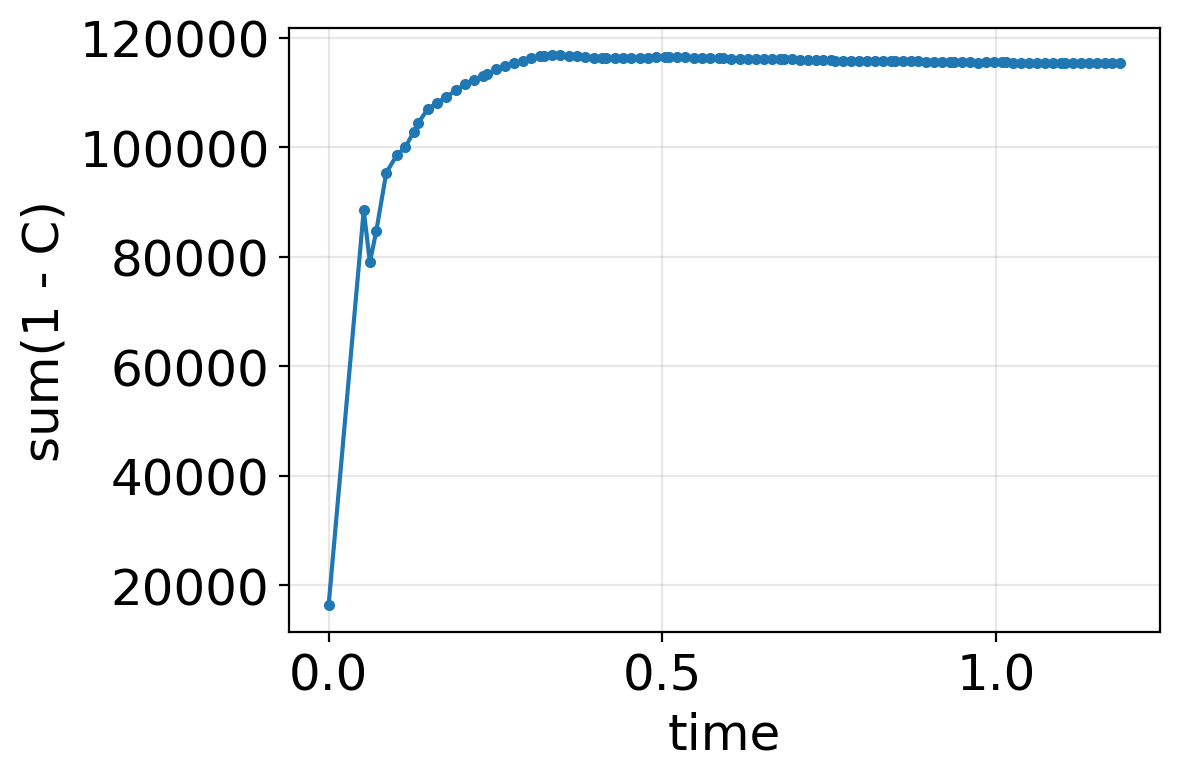

In [54]:
times, Csum = plot_task_timeseries(
    snapshot_dir="snapshots_noerosion",
    file_prefix="snapshots_noerosion_s",
    task="C",
    quantity_func=lambda A: np.sum(1 - A),
    max_frames=100,
    ylabel="sum(1 - C)",
    output_name="Csum_timeseries_noerosion.png",
)

(115000.0, 116000.0)

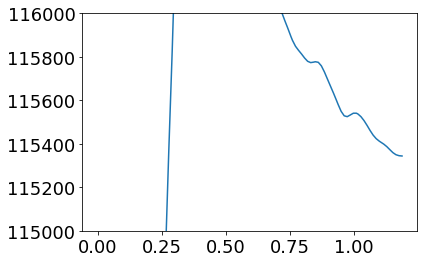

In [55]:
plt.plot(times, Csum)
plt.ylim([115000,116000])

Using 100 frames.
1/100 time=0 value=0
2/100 time=0.0525916 value=1823.98
3/100 time=0.0617937 value=16574.1
4/100 time=0.0714196 value=20425.9
5/100 time=0.0863406 value=15600.1
6/100 time=0.101908 value=16400.9
7/100 time=0.114762 value=18562.2
8/100 time=0.121048 value=18675.3
9/100 time=0.133913 value=18215.4
10/100 time=0.148244 value=17805.6
11/100 time=0.162493 value=17824.7
12/100 time=0.176338 value=17918.5
13/100 time=0.190182 value=17854.9
14/100 time=0.197104 value=17821.5
15/100 time=0.210948 value=17679.6
16/100 time=0.224793 value=17496.5
17/100 time=0.237961 value=17298.1
18/100 time=0.251112 value=17031.5
19/100 time=0.264262 value=16846.3
20/100 time=0.270838 value=16754.6
21/100 time=0.283989 value=16510.8
22/100 time=0.29714 value=16213.8
23/100 time=0.309777 value=15886.3
24/100 time=0.322271 value=15537.8
25/100 time=0.334764 value=15248.7
26/100 time=0.34101 value=15112.8
27/100 time=0.353503 value=14829
28/100 time=0.365996 value=14575.3
29/100 time=0.37849 valu

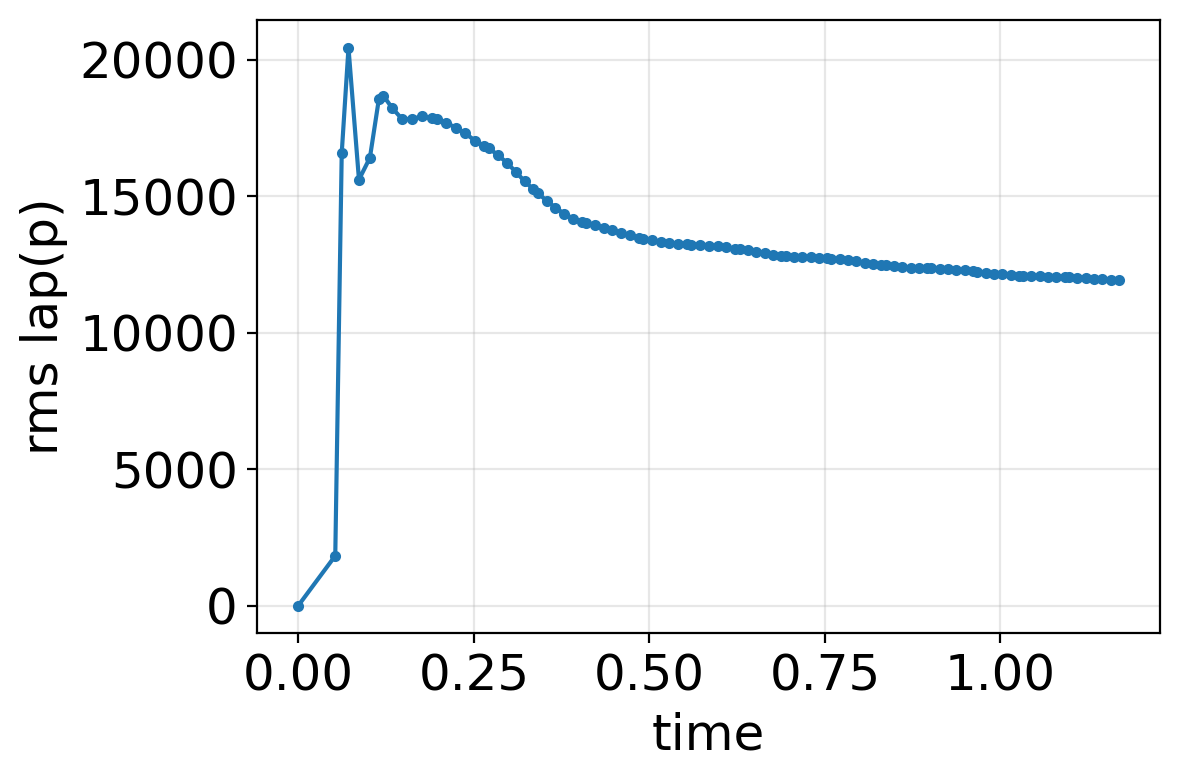

In [52]:
times, Csum = plot_task_timeseries(
    snapshot_dir="snapshots_noerosion",
    file_prefix="snapshots_noerosion_s",
    task="p",
    quantity_func=lambda A: np.sqrt(np.mean(((np.roll(A[:,:,-1], -1, axis=0) - 2*A[:,:,-1] + np.roll(A[:,:,-1], 1, axis=0))/dx**2 + (np.roll(A[:,:,-1], -1, axis=1) - 2*A[:,:,-1] + np.roll(A[:,:,-1], 1, axis=1))/dy**2)**2)),
    max_frames=100,
    ylabel="rms lap(p)",
    output_name="plap_timeseries_noerosion.png",
)

Using 100 frames.
1/100 time=0 value=0
2/100 time=0.0525916 value=89.5485
3/100 time=0.0617937 value=321.339
4/100 time=0.0714196 value=246.582
5/100 time=0.0863406 value=231.938
6/100 time=0.101908 value=235.059
7/100 time=0.114762 value=245.198
8/100 time=0.121048 value=247.698
9/100 time=0.133913 value=241.606
10/100 time=0.148244 value=232.805
11/100 time=0.162493 value=234.342
12/100 time=0.176338 value=235.857
13/100 time=0.190182 value=235.312
14/100 time=0.197104 value=233.436
15/100 time=0.210948 value=231.481
16/100 time=0.224793 value=234.521
17/100 time=0.237961 value=238.488
18/100 time=0.251112 value=242.698
19/100 time=0.264262 value=246.615
20/100 time=0.270838 value=248.448
21/100 time=0.283989 value=252.67
22/100 time=0.29714 value=255.727
23/100 time=0.309777 value=256.443
24/100 time=0.322271 value=257.368
25/100 time=0.334764 value=256.556
26/100 time=0.34101 value=255.87
27/100 time=0.353503 value=255.357
28/100 time=0.365996 value=255.273
29/100 time=0.37849 valu

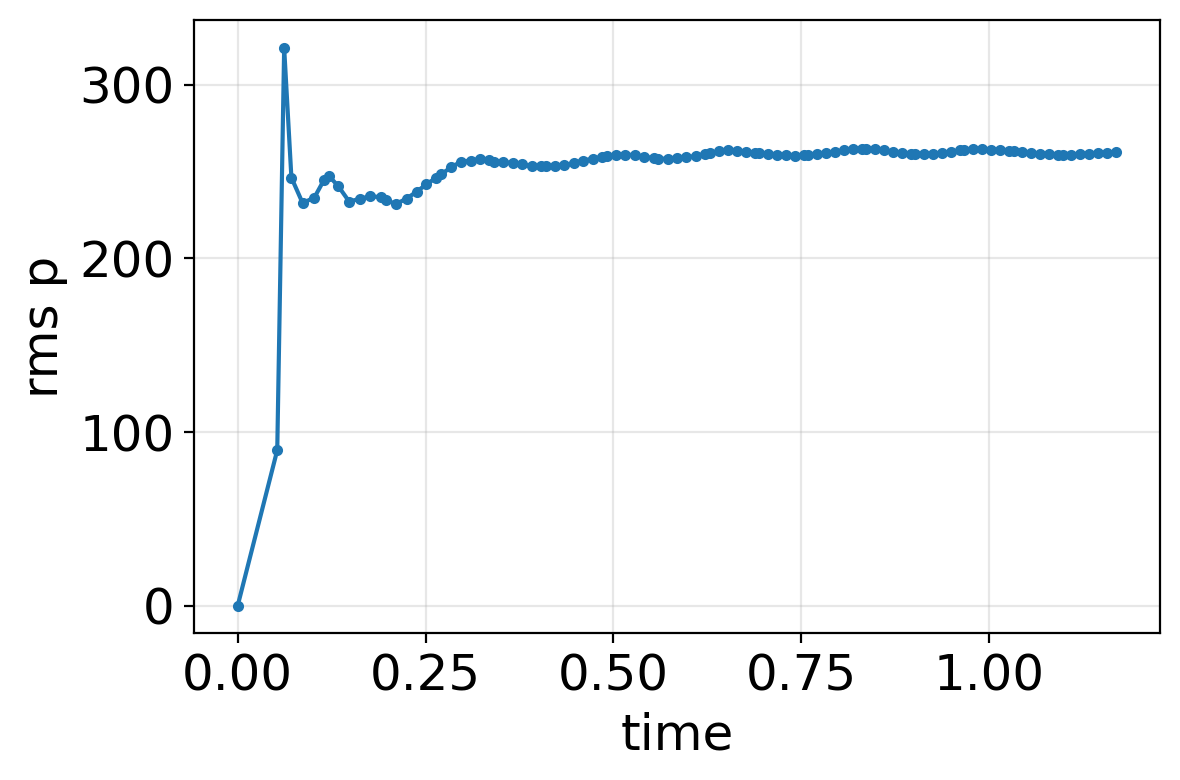

In [50]:
times, Csum = plot_task_timeseries(
    snapshot_dir="snapshots_noerosion",
    file_prefix="snapshots_noerosion_s",
    task="p",
    quantity_func=lambda A: np.sqrt(np.mean((A[:,:,-1] - np.mean(A[:,:,-1]))**2)),
    max_frames=100,
    ylabel="rms p",
    output_name="p_timeseries_noerosion.png",
)

Using 100 frames.
1/100 time=0 value=0
2/100 time=0.0525916 value=186807
3/100 time=0.0617937 value=5.42714e+06
4/100 time=0.0714196 value=6.61314e+06
5/100 time=0.0863406 value=5.03859e+06
6/100 time=0.101908 value=5.31551e+06
7/100 time=0.114762 value=6.09073e+06
8/100 time=0.121048 value=6.07295e+06
9/100 time=0.133913 value=5.72951e+06
10/100 time=0.148244 value=5.42156e+06
11/100 time=0.162493 value=5.36568e+06
12/100 time=0.176338 value=5.37511e+06
13/100 time=0.190182 value=5.31073e+06
14/100 time=0.197104 value=5.27075e+06
15/100 time=0.210948 value=5.19295e+06
16/100 time=0.224793 value=5.15178e+06
17/100 time=0.237961 value=5.10766e+06
18/100 time=0.251112 value=5.04852e+06
19/100 time=0.264262 value=5.02431e+06
20/100 time=0.270838 value=5.01341e+06
21/100 time=0.283989 value=4.97688e+06
22/100 time=0.29714 value=4.93182e+06
23/100 time=0.309777 value=4.86503e+06
24/100 time=0.322271 value=4.78787e+06
25/100 time=0.334764 value=4.73103e+06
26/100 time=0.34101 value=4.70566e+

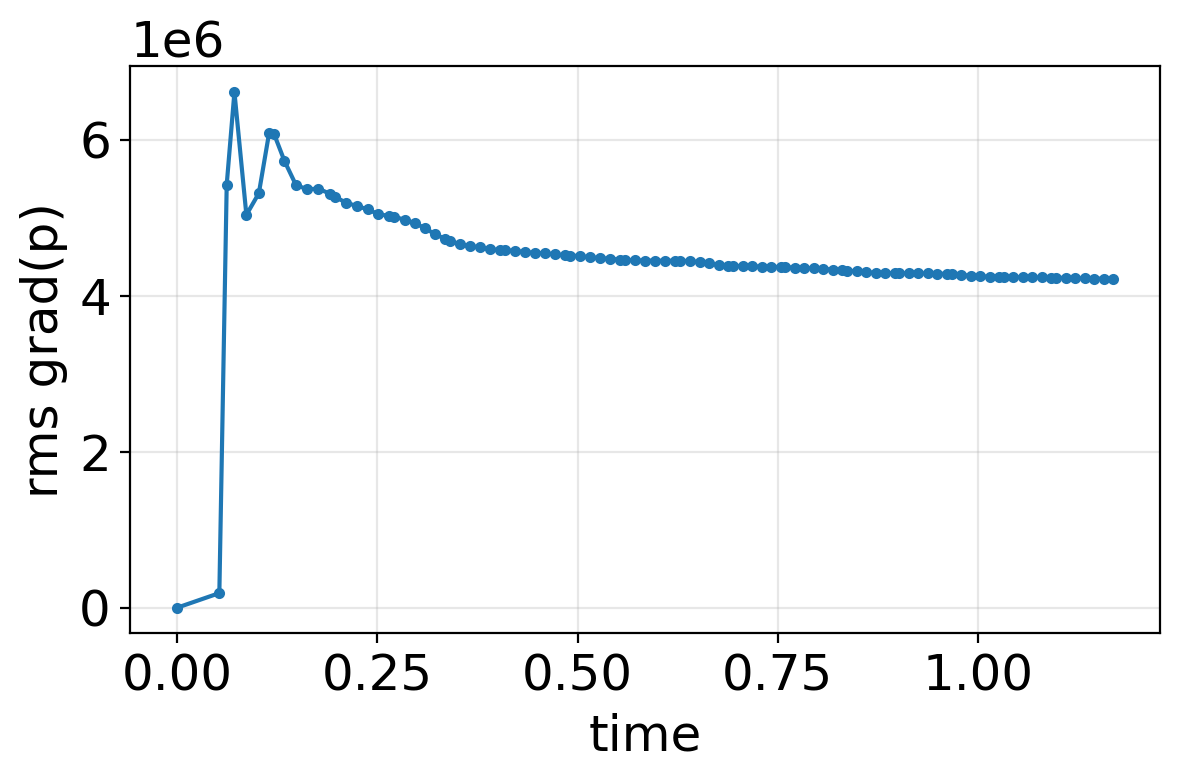

In [53]:
times, Csum = plot_task_timeseries(
    snapshot_dir="snapshots_noerosion",
    file_prefix="snapshots_noerosion_s",
    task="p",
    quantity_func=lambda A: np.sqrt(np.mean(((np.roll(A[:,:,-1],-1,axis=0) - A[:,:,-1])**2/dx**2 + (np.roll(A[:,:,-1],-1,axis=1) - A[:,:,-1])**2/dy**2)**2)),
    max_frames=100,
    ylabel="rms grad(p)",
    output_name="pgrad_timeseries_noerosion.png",
)